In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Read dataset
df = pd.read_csv(r"E:\Project_Analysis\Nutri_Class_project\Data\synthetic_food_dataset_imbalanced.csv")

In [3]:
df.shape

(31700, 16)

In [4]:
df.isnull().sum()

Calories              375
Protein               375
Fat                   375
Carbs                 375
Sugar                 375
Fiber                 375
Sodium                375
Cholesterol           375
Glycemic_Index        375
Water_Content         375
Serving_Size          375
Meal_Type               0
Preparation_Method      0
Is_Vegan                0
Is_Gluten_Free          0
Food_Name               0
dtype: int64

In [5]:
df.notnull().sum()

Calories              31325
Protein               31325
Fat                   31325
Carbs                 31325
Sugar                 31325
Fiber                 31325
Sodium                31325
Cholesterol           31325
Glycemic_Index        31325
Water_Content         31325
Serving_Size          31325
Meal_Type             31700
Preparation_Method    31700
Is_Vegan              31700
Is_Gluten_Free        31700
Food_Name             31700
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31700 entries, 0 to 31699
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Calories            31325 non-null  float64
 1   Protein             31325 non-null  float64
 2   Fat                 31325 non-null  float64
 3   Carbs               31325 non-null  float64
 4   Sugar               31325 non-null  float64
 5   Fiber               31325 non-null  float64
 6   Sodium              31325 non-null  float64
 7   Cholesterol         31325 non-null  float64
 8   Glycemic_Index      31325 non-null  float64
 9   Water_Content       31325 non-null  float64
 10  Serving_Size        31325 non-null  float64
 11  Meal_Type           31700 non-null  object 
 12  Preparation_Method  31700 non-null  object 
 13  Is_Vegan            31700 non-null  bool   
 14  Is_Gluten_Free      31700 non-null  bool   
 15  Food_Name           31700 non-null  object 
dtypes: b

In [7]:
df.head()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,197.570043,dinner,fried,False,False,Pizza
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,103.833510,snack,raw,False,True,Ice Cream
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,198.989367,snack,raw,False,False,Burger
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,135.714202,lunch,fried,False,True,Sushi
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,73.019474,snack,baked,False,False,Donut


In [8]:
# Drop missing values
df_clean = df.dropna().copy()
print("After removing NaNs:", df_clean.shape)

After removing NaNs: (31325, 16)


<Axes: ylabel='Protein'>

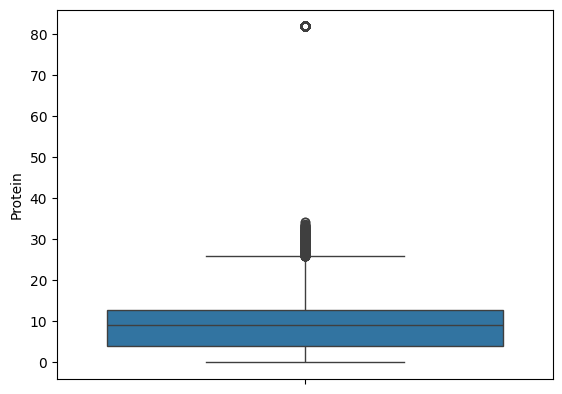

In [9]:
sns.boxplot(data=df_clean["Protein"] )

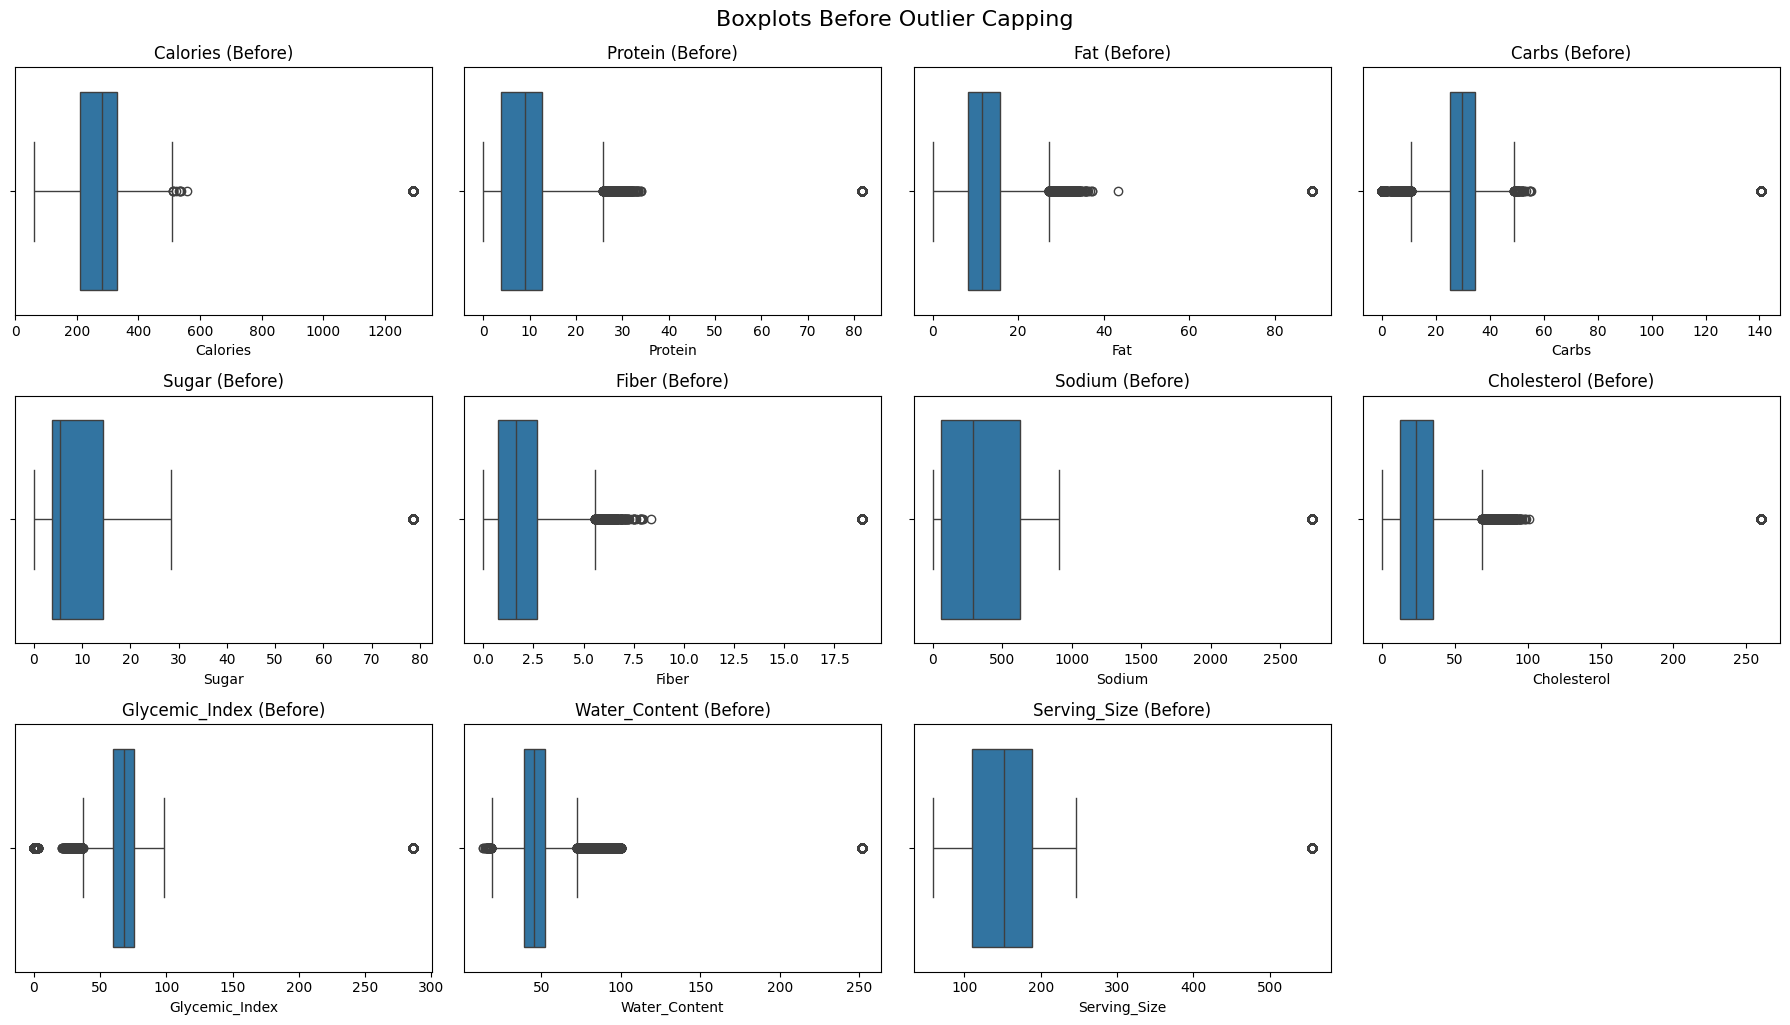

In [10]:

# Columns to treat
cols = [
    'Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium',
    'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size'
]
plt.figure(figsize=(18, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x=df_clean[col])
    plt.title(f"{col} (Before)")
    plt.tight_layout()

plt.suptitle("Boxplots Before Outlier Capping", fontsize=16, y=1.02)
plt.show()

Calories: capped to [31.02, 509.10]
Protein: capped to [-9.38, 25.92]
Fat: capped to [-3.11, 27.18]
Carbs: capped to [10.79, 48.94]
Sugar: capped to [-12.29, 30.46]
Fiber: capped to [-2.15, 5.56]
Sodium: capped to [-789.55, 1483.92]
Cholesterol: capped to [-20.94, 68.78]
Glycemic_Index: capped to [36.76, 98.68]
Water_Content: capped to [18.89, 72.51]
Serving_Size: capped to [-9.85, 308.44]
Final shape after capping: (31325, 16)


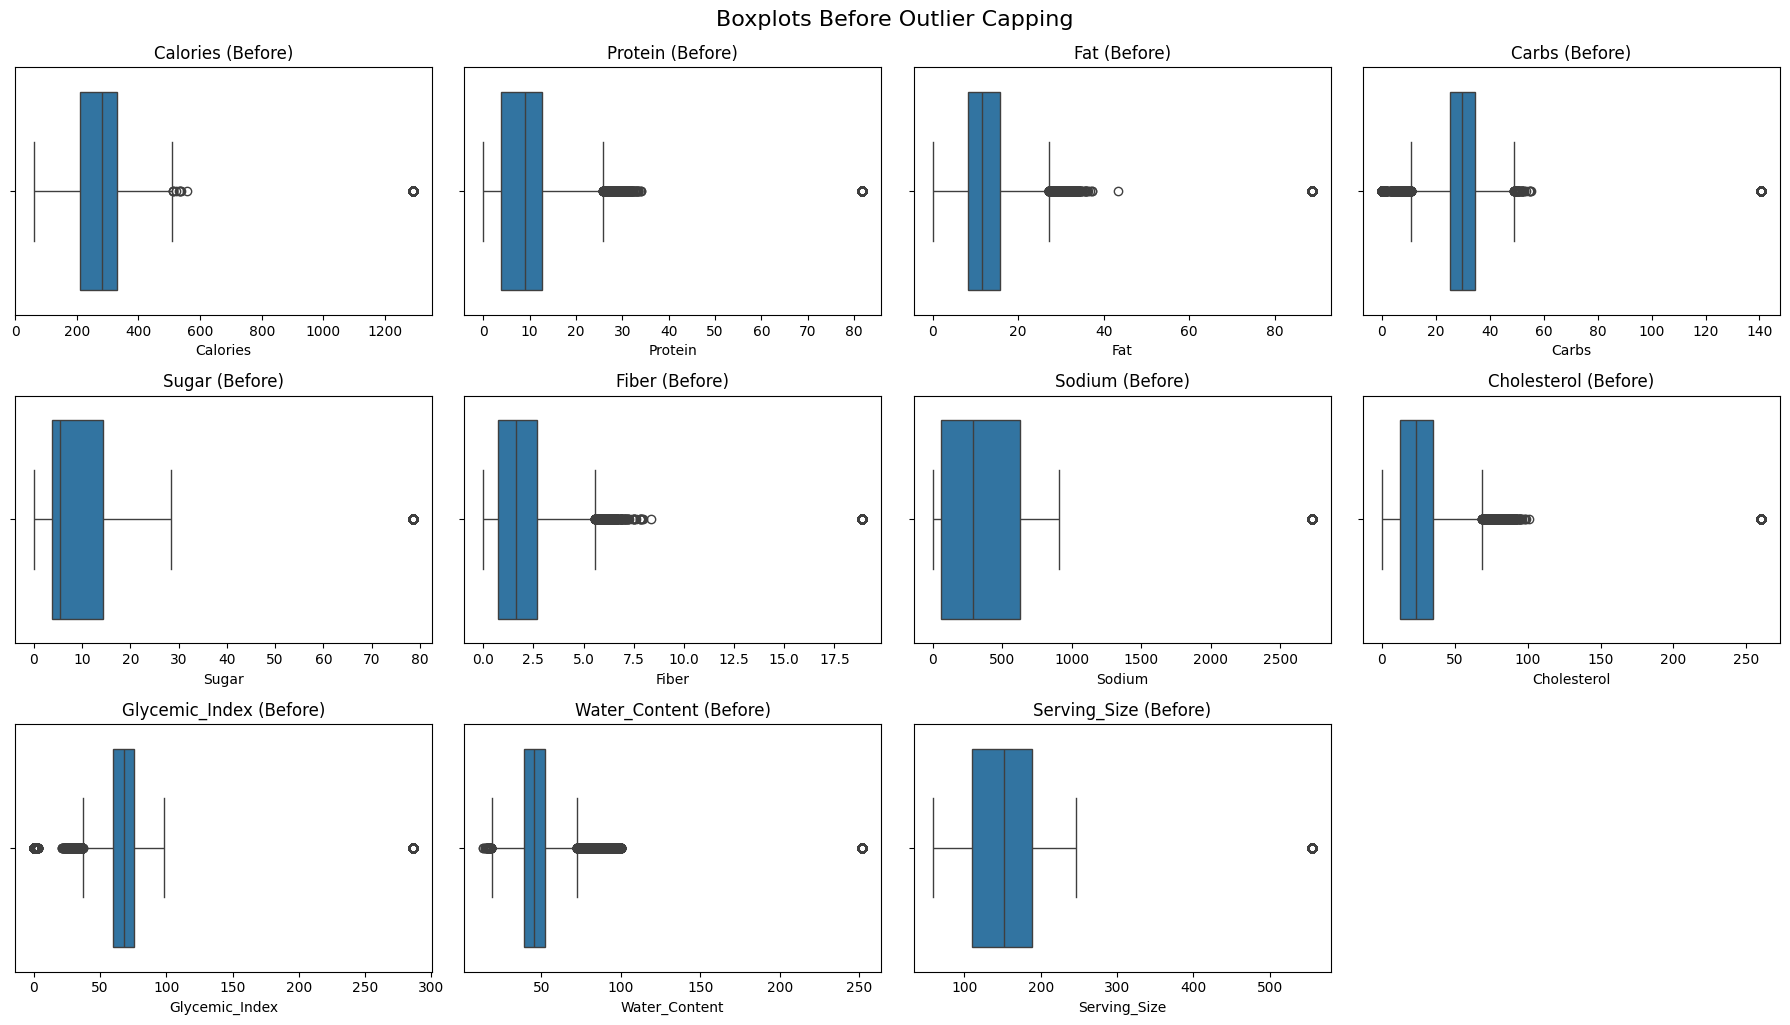

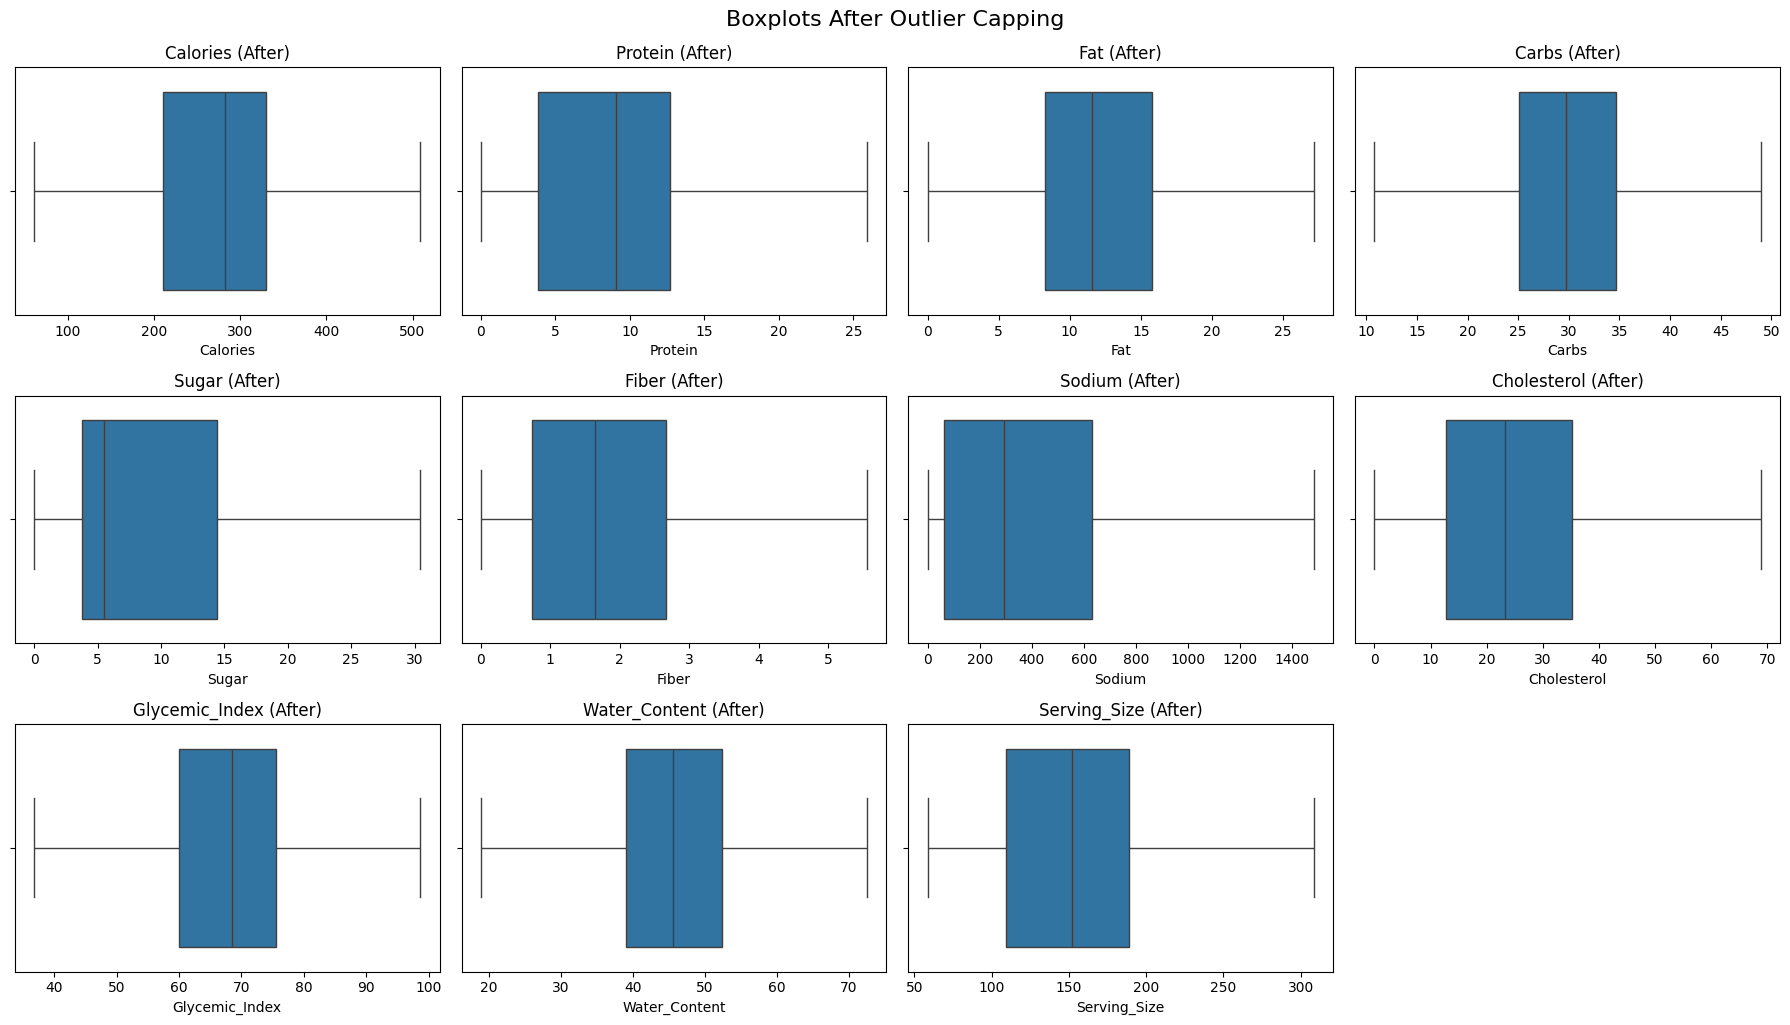

In [11]:

# Columns to treat
cols = [
    'Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium',
    'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size'
]

# Copy dataset
df_capped = df_clean.copy()

# IQR-based capping for multiple columns
for col in cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_capped[col] = np.where(
        df_capped[col] >= upper_bound, upper_bound,
        np.where(df_capped[col] <= lower_bound, lower_bound, df_capped[col])
    )

    print(f"{col}: capped to [{lower_bound:.2f}, {upper_bound:.2f}]")

print("Final shape after capping:", df_capped.shape)

plt.figure(figsize=(18, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x=df_clean[col])
    plt.title(f"{col} (Before)")
    plt.tight_layout()

plt.suptitle("Boxplots Before Outlier Capping", fontsize=16, y=1.02)
plt.show()

plt.figure(figsize=(18, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x=df_capped[col])
    plt.title(f"{col} (After)")
    plt.tight_layout()

plt.suptitle("Boxplots After Outlier Capping", fontsize=16, y=1.02)
plt.show()

# Data Encoding ---> LabelEncoder and OneHotEncoder - Categorical Features

In [12]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import pandas as pd

# Separate LabelEncoders
le_vegan = LabelEncoder()
le_gluten = LabelEncoder()
le_food = LabelEncoder()

df_capped["Is_Vegan_label"] = le_vegan.fit_transform(df_capped["Is_Vegan"])
df_capped["Is_Gluten_Free_label"] = le_gluten.fit_transform(df_capped["Is_Gluten_Free"])
df_capped["Food_Name_label"] = le_food.fit_transform(df_capped["Food_Name"])

# Drop the original categorical columns AFTER encoding
df_capped.drop(columns=["Is_Vegan", "Is_Gluten_Free", "Food_Name"], inplace=True)

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

ohe_array = ohe.fit_transform(
    df_capped[["Meal_Type", "Preparation_Method"]]
)

ohe_df = pd.DataFrame(
    ohe_array,
    columns=ohe.get_feature_names_out(["Meal_Type", "Preparation_Method"]),
    index=df_capped.index
)

df_new = pd.concat(
    [
        df_capped.drop(columns=["Meal_Type", "Preparation_Method"]),
        ohe_df
    ],
    axis=1
)

df_new.head()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,...,Is_Gluten_Free_label,Food_Name_label,Meal_Type_breakfast,Meal_Type_dinner,Meal_Type_lunch,Meal_Type_snack,Preparation_Method_baked,Preparation_Method_fried,Preparation_Method_grilled,Preparation_Method_raw
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,...,0,6,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,...,1,4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,...,0,2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,...,1,9,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,...,0,3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [13]:
df_new.columns

Index(['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium',
       'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size',
       'Is_Vegan_label', 'Is_Gluten_Free_label', 'Food_Name_label',
       'Meal_Type_breakfast', 'Meal_Type_dinner', 'Meal_Type_lunch',
       'Meal_Type_snack', 'Preparation_Method_baked',
       'Preparation_Method_fried', 'Preparation_Method_grilled',
       'Preparation_Method_raw'],
      dtype='object')

In [14]:

# Save cleaned & encoded dataset
output_path = r"E:\Project_Analysis\Nutri_Class_project\Data\cleaned_encoded_food_dataset.csv"
df_new.to_csv(output_path, index=False)

print(f"Saved cleaned dataset to: {output_path}")

Saved cleaned dataset to: E:\Project_Analysis\Nutri_Class_project\Data\cleaned_encoded_food_dataset.csv


In [15]:
import pickle

with open("le_vegan.pkl", "wb") as f:
    pickle.dump(le_vegan, f)

with open("le_gluten.pkl", "wb") as f:
    pickle.dump(le_gluten, f)

with open("le_food.pkl", "wb") as f:
    pickle.dump(le_food, f)

print("Label Encoders saved")

Label Encoders saved


In [16]:
with open("ohe_encoder.pkl", "wb") as f:
    pickle.dump(ohe, f)

print("OneHot Encoder saved")

OneHot Encoder saved
